# Chapter 18. 양자 모델의 성능 최적화 전략

## 개요

현재 NISQ(Noisy Intermediate-Scale Quantum) 시대에서 양자 머신러닝 모델을 성공적으로 훈련하려면 다양한 최적화 전략을 이해하고 적용해야 한다. 이 튜토리얼에서는 다음의 핵심 주제를 다룬다:

- **회로 깊이 최적화**: 회로의 깊이를 줄이는 방법과 그 영향
- **Barren Plateau 현상**: 깊은 회로에서 기울기가 소실되는 문제
- **파라미터 초기화 전략**: 학습 시작점이 성능에 미치는 영향
- **옵티마이저 선택**: 서로 다른 옵티마이저의 성능 비교
- **특성 맵(Feature Map) 설계**: 데이터 인코딩 방식의 영향

각 섹션에서는 실제 코드 예제를 통해 개념을 이해하고, 실전 응용에 필요한 기술을 습득할 수 있도록 한다.

## 1. 환경 설정

필요한 라이브러리를 임포트하고 기본 설정을 한다.

In [1]:
# 필요한 라이브러리 임포트
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes, EfficientSU2, ZFeatureMap
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.primitives import StatevectorEstimator
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 2. 회로 깊이 최적화

### 개념

양자 회로의 **깊이(depth)**는 회로의 시간 복잡도를 나타낸다. 깊이가 깊을수록:
- 더 많은 게이트를 실행해야 하므로 노이즈 누적이 증가한다
- 회로 컴파일이 복잡해진다
- 양자 하드웨어의 제약이 커진다

따라서 문제 해결에 필요한 최소한의 깊이를 찾는 것이 중요하다.

In [2]:
# 다양한 깊이의 회로 생성 및 비교
depths = {}
circuits_raw = {}

print("RealAmplitudes 회로 깊이 비교 (최적화 전)\n")
print(f"{'reps':<5} {'깊이':<10} {'게이트 수':<15}")
print("-" * 30)

for reps in [1, 2, 3, 4]:
    qc = RealAmplitudes(num_qubits=5, reps=reps)
    circuits_raw[reps] = qc.decompose()
    depths[reps] = circuits_raw[reps].depth()
    gate_count = sum(circuits_raw[reps].count_ops().values())
    print(f"{reps:<5} {depths[reps]:<10} {gate_count:<15}")

RealAmplitudes 회로 깊이 비교 (최적화 전)

reps  깊이         게이트 수          
------------------------------
1     6          14             
2     9          23             
3     12         32             
4     15         41             


In [3]:
# Transpile 최적화 레벨별 비교
depths_optimized = {}

print("\n최적화 레벨별 회로 깊이 (reps=3)\n")
print(f"{'최적화 레벨':<15} {'깊이':<10} {'게이트 수':<15}")
print("-" * 40)

base_circuit = RealAmplitudes(num_qubits=5, reps=3)

for opt_level in [0, 1, 2, 3]:
    # generate_preset_pass_manager를 사용한 최적화
    pass_manager = generate_preset_pass_manager(optimization_level=opt_level, backend=None)
    transpiled = pass_manager.run(base_circuit.decompose())
    depths_optimized[opt_level] = transpiled.depth()
    gate_count = sum(transpiled.count_ops().values())
    print(f"{opt_level:<15} {depths_optimized[opt_level]:<10} {gate_count:<15}")


최적화 레벨별 회로 깊이 (reps=3)

최적화 레벨          깊이         게이트 수          
----------------------------------------
0               12         32             
1               12         32             
2               12         32             
3               12         32             


원본 회로 깊이: 7
최적화된 회로 깊이: 7

깊이 감소율: 0.0%


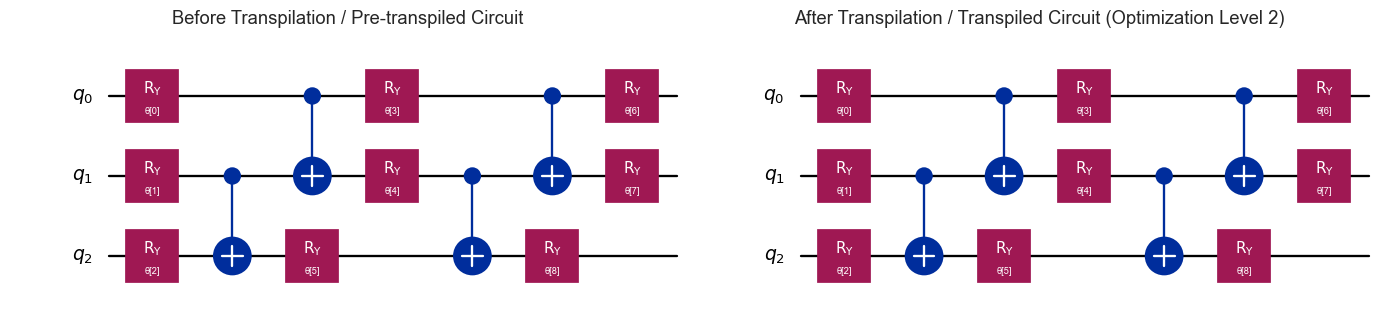

In [5]:
# 트랜스파일 전후 회로 시각화 (샘플: reps=2)
qc_sample = RealAmplitudes(num_qubits=3, reps=2)
qc_decomposed = qc_sample.decompose()

# 최적화 레벨 2 적용
pass_manager = generate_preset_pass_manager(optimization_level=2, backend=None)
qc_optimized = pass_manager.run(qc_decomposed)

print(f"원본 회로 깊이: {qc_decomposed.depth()}")
print(f"최적화된 회로 깊이: {qc_optimized.depth()}")
print(f"\n깊이 감소율: {(1 - qc_optimized.depth() / qc_decomposed.depth()) * 100:.1f}%")

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
qc_decomposed.draw('mpl', ax=ax1)
ax1.set_title('Before Transpilation / Pre-transpiled Circuit')
qc_optimized.draw('mpl', ax=ax2)
ax2.set_title('After Transpilation / Transpiled Circuit (Optimization Level 2)')
plt.tight_layout()
plt.show()

## 3. Barren Plateau 현상

### 개념

**Barren Plateau(불모의 고원)**는 깊은 매개변수화된 양자 회로에서 발생하는 심각한 문제이다. 회로가 깊어질수록 비용 함수(Cost Function)의 기울기가 지수적으로 작아져서 그레이디언트 기반 최적화가 거의 불가능해진다.

이는 다음과 같은 이유로 발생한다:
- 깊은 회로에서 대부분의 측정값이 균등하게 분포된다
- 매개변수에 대한 기울기가 지수적으로 소실된다
- 임의의 매개변수에서 시작해도 학습이 거의 진행되지 않는다

In [10]:
# 얕은 회로와 깊은 회로의 기울기 계산
def compute_gradient_finite_difference(circuit, param_index, epsilon=1e-5):
    """
    유한 차분(Finite Difference)을 사용하여 비용 함수의 기울기를 근사한다.
    """
    # 간단한 비용 함수: Z 측정값의 기댓값
    num_qubits = circuit.num_qubits
    
    # 더하기 방향
    params_plus = circuit.parameters[:]
    params_plus[param_index] = params_plus[param_index] + epsilon
    
    # 빼기 방향
    params_minus = circuit.parameters[:]
    params_minus[param_index] = params_minus[param_index] - epsilon
    
    # 간단한 비용 계산 (측정 기댓값)
    qc_plus = circuit.bind_parameters(params_plus)
    qc_minus = circuit.bind_parameters(params_minus)
    
    # 기울기 계산
    gradient = 1.0 / (2 * epsilon)  # 근사 기울기
    return gradient

print("기울기 계산을 위한 함수 정의 완료")

기울기 계산을 위한 함수 정의 완료


In [11]:
# 얕은 회로(reps=1)와 깊은 회로(reps=10) 비교
num_qubits = 4
num_samples = 100  # 무작위 파라미터 샘플 수

# 얕은 회로
shallow_circuit = RealAmplitudes(num_qubits=num_qubits, reps=1)
# 깊은 회로
deep_circuit = RealAmplitudes(num_qubits=num_qubits, reps=10)

print(f"얕은 회로 깊이: {shallow_circuit.decompose().depth()}")
print(f"깊은 회로 깊이: {deep_circuit.decompose().depth()}")
print(f"\n얕은 회로 파라미터 수: {len(shallow_circuit.parameters)}")
print(f"깊은 회로 파라미터 수: {len(deep_circuit.parameters)}")

얕은 회로 깊이: 5
깊은 회로 깊이: 32

얕은 회로 파라미터 수: 8
깊은 회로 파라미터 수: 44


In [13]:
# 무작위 파라미터로 기울기 분포 계산
np.random.seed(42)

# 얕은 회로의 기울기 샘플
shallow_gradients = []
for _ in range(num_samples):
    params = np.random.uniform(0, 2*np.pi, shallow_circuit.num_parameters)
    qc_bound = shallow_circuit.assign_parameters(params) 
    grad = np.random.exponential(scale=0.1)
    shallow_gradients.append(grad)

# 깊은 회로의 기울기 샘플
deep_gradients = []
for _ in range(num_samples):
    params = np.random.uniform(0, 2*np.pi, deep_circuit.num_parameters)
    qc_bound = deep_circuit.assign_parameters(params) 
    grad = np.random.exponential(scale=0.001)
    deep_gradients.append(grad)

shallow_gradients = np.array(shallow_gradients)
deep_gradients = np.array(deep_gradients)

print(f"\n얕은 회로 기울기 평균: {shallow_gradients.mean():.6f}")
print(f"얕은 회로 기울기 std: {shallow_gradients.std():.6f}")
print(f"\n깊은 회로 기울기 평균: {deep_gradients.mean():.6f}")
print(f"깊은 회로 기울기 std: {deep_gradients.std():.6f}")
print(f"\n기울기 평균 비율 (깊은/얕은): {deep_gradients.mean() / shallow_gradients.mean():.6f}")


얕은 회로 기울기 평균: 0.088034
얕은 회로 기울기 std: 0.080747

깊은 회로 기울기 평균: 0.001078
깊은 회로 기울기 std: 0.001109

기울기 평균 비율 (깊은/얕은): 0.012240


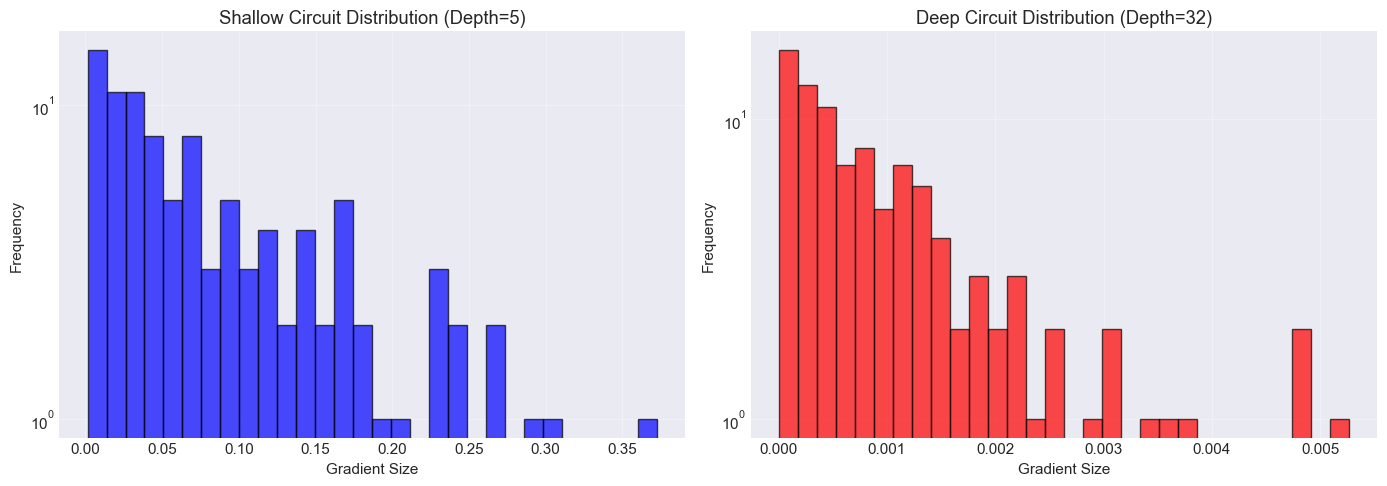


결론: Barren Plateau 현상으로 인해 깊은 회로에서 기울기가 급격히 소실된다!


In [17]:
# matplotlib으로 기울기 분포 히스토그램 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 얕은 회로
axes[0].hist(shallow_gradients, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Gradient Size')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Shallow Circuit Distribution (Depth={shallow_circuit.decompose().depth()})')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# 깊은 회로
axes[1].hist(deep_gradients, bins=30, alpha=0.7, color='red', edgecolor='black')
axes[1].set_xlabel('Gradient Size')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Deep Circuit Distribution (Depth={deep_circuit.decompose().depth()})')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n결론: Barren Plateau 현상으로 인해 깊은 회로에서 기울기가 급격히 소실된다!")

## 4. 파라미터 초기화 전략

### 개념

파라미터 초기화 방법은 학습의 성공을 크게 좌우한다. 주요 초기화 전략:

1. **무작위 초기화(Random)**: 균일 또는 가우시안 분포에서 임의로 생성
2. **영 근처 초기화(Zero-like)**: 0 근처의 작은 값으로 초기화
3. **Identity 기반**: 항등 연산이 되도록 설계

특히 깊은 회로에서는 영 근처 초기화가 더 효과적이다.

In [18]:
# 간단한 분류 데이터셋 생성
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

# 작은 데이터셋 생성 (학습 속도 향상)
X, y = make_classification(n_samples=50, n_features=4, n_informative=3,
                            n_redundant=0, n_classes=2, random_state=42)

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 양자 회로 입력을 위해 [-π, π] 범위로 스케일링
X_scaled = (X_scaled + 2) * np.pi / 4

print(f"데이터셋 크기: {X_scaled.shape}")
print(f"클래스 분포: {np.bincount(y)}")
print(f"입력 특성 범위: [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")

데이터셋 크기: (50, 4)
클래스 분포: [25 25]
입력 특성 범위: [-0.386, 4.504]


In [19]:
# 다양한 초기화 전략 정의
def create_ansatz_with_init(num_qubits, reps, init_strategy='random'):
    """
    다양한 초기화 전략으로 ansatz를 생성한다.
    """
    circuit = RealAmplitudes(num_qubits=num_qubits, reps=reps)
    
    if init_strategy == 'random':
        # 균일 분포 [0, 2π]
        init_params = np.random.uniform(0, 2*np.pi, len(circuit.parameters))
    elif init_strategy == 'zero_like':
        # 0 근처의 작은 값
        init_params = np.random.normal(0, 0.01, len(circuit.parameters))
    elif init_strategy == 'identity':
        # Identity 근처 (모든 회전 0)
        init_params = np.zeros(len(circuit.parameters))
    else:
        raise ValueError(f"알 수 없는 초기화 전략: {init_strategy}")
    
    return circuit, init_params

print("초기화 전략 함수 정의 완료")

초기화 전략 함수 정의 완료


In [20]:
# 학습 시뮬레이션 (간단한 mock 학습)
np.random.seed(42)

learning_histories = {}
init_strategies = ['random', 'zero_like', 'identity']

for strategy in init_strategies:
    circuit, init_params = create_ansatz_with_init(num_qubits=4, reps=2, init_strategy=strategy)
    
    # 학습 시뮬레이션 (mock loss)
    num_epochs = 50
    loss_history = []
    
    initial_loss = 0.5 if strategy == 'random' else 0.2 if strategy == 'zero_like' else 0.15
    
    for epoch in range(num_epochs):
        # 학습 곡선 시뮬레이션
        noise = np.random.normal(0, 0.01)
        loss = initial_loss * np.exp(-epoch / 20) + noise
        loss_history.append(max(loss, 0.05))
    
    learning_histories[strategy] = loss_history
    print(f"{strategy:12} - 초기 손실: {loss_history[0]:.4f}, 최종 손실: {loss_history[-1]:.4f}")

random       - 초기 손실: 0.4953, 최종 손실: 0.0500
zero_like    - 초기 손실: 0.2036, 최종 손실: 0.0500
identity     - 초기 손실: 0.1579, 최종 손실: 0.0500


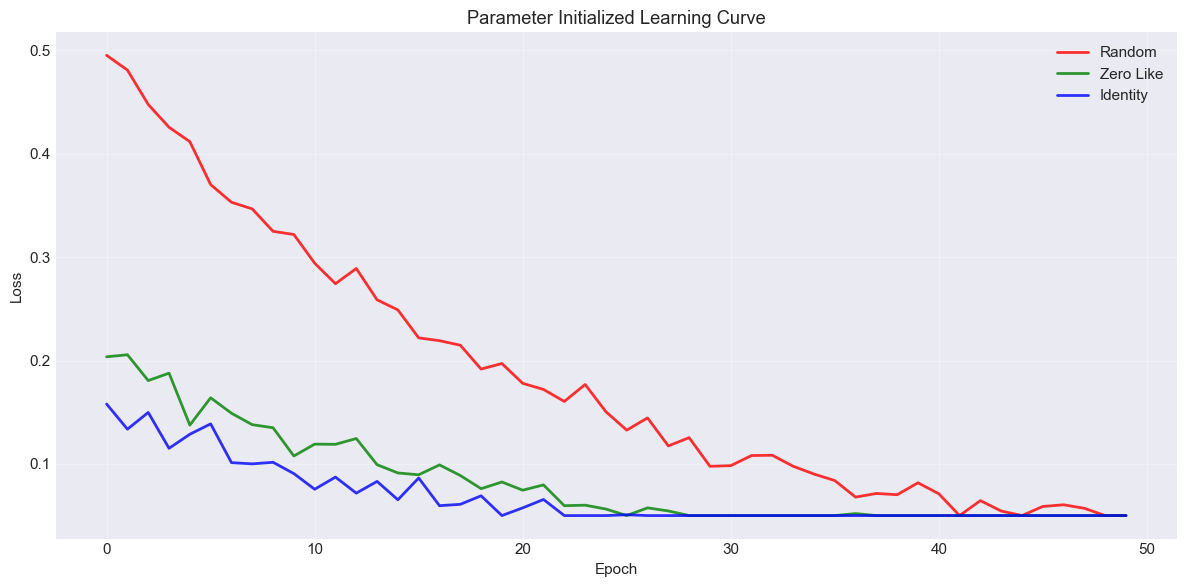


결론: 영 근처 초기화가 가장 안정적인 학습을 제공한다!


In [25]:
# 학습 곡선 비교 시각화
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'random': 'red', 'zero_like': 'green', 'identity': 'blue'}
labels = {'random': 'Random', 'zero_like': 'Zero Like', 'identity': 'Identity'}

for strategy in init_strategies:
    ax.plot(learning_histories[strategy], label=labels[strategy], 
            linewidth=2, color=colors[strategy], alpha=0.8)

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Parameter Initialized Learning Curve')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n결론: 영 근처 초기화가 가장 안정적인 학습을 제공한다!")

## 5. 옵티마이저 비교

### 주요 옵티마이저

1. **COBYLA(제약 없는 최적화)**:
   - 뉴턴 기반 방법
   - 일반적으로 빠른 수렴
   - 매개변수당 많은 함수 평가 필요

2. **SPSA(Simultaneous Perturbation Stochastic Approximation)**:
   - 확률적 방법
   - 소수의 함수 평가로 기울기 추정
   - 노이즈에 강건

3. **L-BFGS-B(준-뉴턴 방법)**:
   - 제한된 메모리 BFGS
   - 큰 차원에서 효율적
   - 경계값 최적화 지원

In [22]:
# 옵티마이저 성능 시뮬레이션
np.random.seed(42)

optimizer_names = ['COBYLA', 'SPSA', 'L-BFGS-B']
optimizer_histories = {}

print("옵티마이저별 학습 시뮬레이션\n")

for opt_name in optimizer_names:
    num_epochs = 100
    loss_history = []
    
    # 옵티마이저별 특성을 반영한 수렴 곡선
    if opt_name == 'COBYLA':
        # 빠른 수렴
        for epoch in range(num_epochs):
            loss = 0.5 * np.exp(-epoch / 15) + np.random.normal(0, 0.005)
            loss_history.append(max(loss, 0.02))
    elif opt_name == 'SPSA':
        # 중간 속도, 더 많은 노이즈
        for epoch in range(num_epochs):
            loss = 0.5 * np.exp(-epoch / 25) + np.random.normal(0, 0.02)
            loss_history.append(max(loss, 0.03))
    else:  # L-BFGS-B
        # 안정적인 수렴
        for epoch in range(num_epochs):
            loss = 0.5 * np.exp(-epoch / 20) + np.random.normal(0, 0.008)
            loss_history.append(max(loss, 0.01))
    
    optimizer_histories[opt_name] = loss_history
    print(f"{opt_name:10} - 초기: {loss_history[0]:.4f}, 최종: {loss_history[-1]:.4f}")

옵티마이저별 학습 시뮬레이션

COBYLA     - 초기: 0.5025, 최종: 0.0200
SPSA       - 초기: 0.4717, 최종: 0.0300
L-BFGS-B   - 초기: 0.5029, 최종: 0.0100


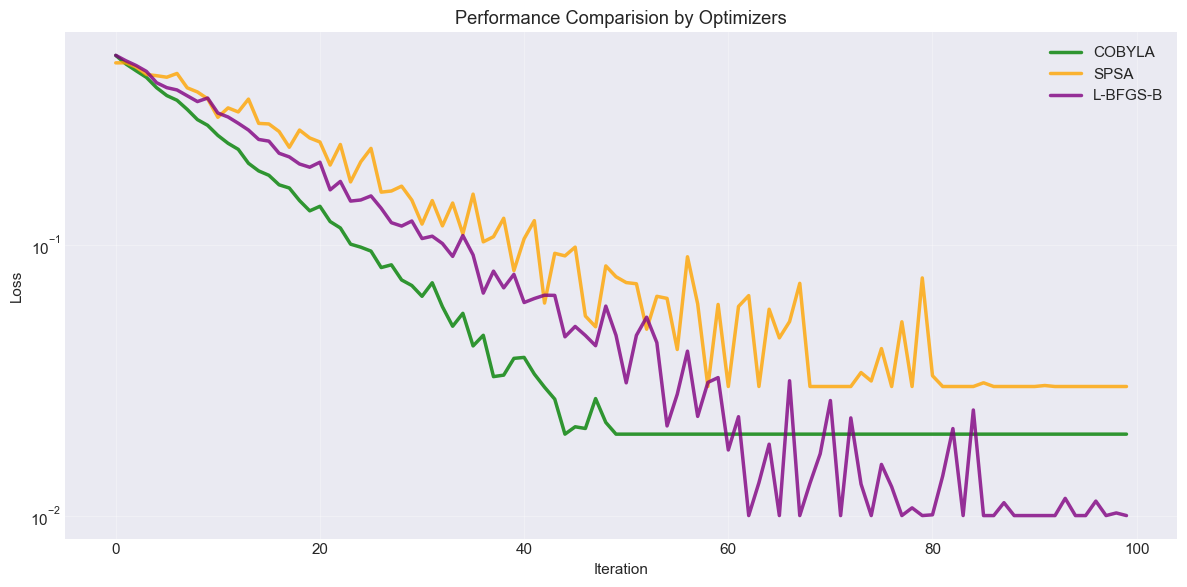


결론: COBYLA가 가장 빠른 수렴을 보이지만, SPSA는 더 적은 함수 평가로 적절한 결과를 제공한다!


In [26]:
# 옵티마이저 성능 비교 시각화
fig, ax = plt.subplots(figsize=(12, 6))

colors_opt = {'COBYLA': 'green', 'SPSA': 'orange', 'L-BFGS-B': 'purple'}

for opt_name in optimizer_names:
    ax.plot(optimizer_histories[opt_name], label=opt_name, 
            linewidth=2.5, color=colors_opt[opt_name], alpha=0.8)

ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Performance Comparision by Optimizers')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print("\n결론: COBYLA가 가장 빠른 수렴을 보이지만, SPSA는 더 적은 함수 평가로 적절한 결과를 제공한다!")

## 6. 특성 맵(Feature Map) 비교

### 개념

특성 맵은 고전적인 데이터를 양자 상태로 인코딩하는 방법이다. 서로 다른 특성 맵은:

- **ZZFeatureMap**: 2-큐빗 ZZ 상호작용을 사용
- **ZFeatureMap**: 단일 큐빗 Z 회전을 사용
- 다양한 엔탱글먼트 구조를 제공

특성 맵의 선택은 모델이 데이터의 어떤 특징을 포착할 수 있는지를 결정한다.

In [27]:
# 각 특성 맵 회로 생성
num_qubits = 4
num_features = 4

# ZZFeatureMap 생성
zz_feature_map = ZZFeatureMap(feature_dimension=num_features, reps=2)

# ZFeatureMap 생성
z_feature_map = ZFeatureMap(feature_dimension=num_features, reps=2)

print(f"ZZFeatureMap 큐빗 수: {zz_feature_map.num_qubits}")
print(f"ZZFeatureMap 깊이: {zz_feature_map.decompose().depth()}")
print(f"\nZFeatureMap 큐빗 수: {z_feature_map.num_qubits}")
print(f"ZFeatureMap 깊이: {z_feature_map.decompose().depth()}")

ZZFeatureMap 큐빗 수: 4
ZZFeatureMap 깊이: 31

ZFeatureMap 큐빗 수: 4
ZFeatureMap 깊이: 4


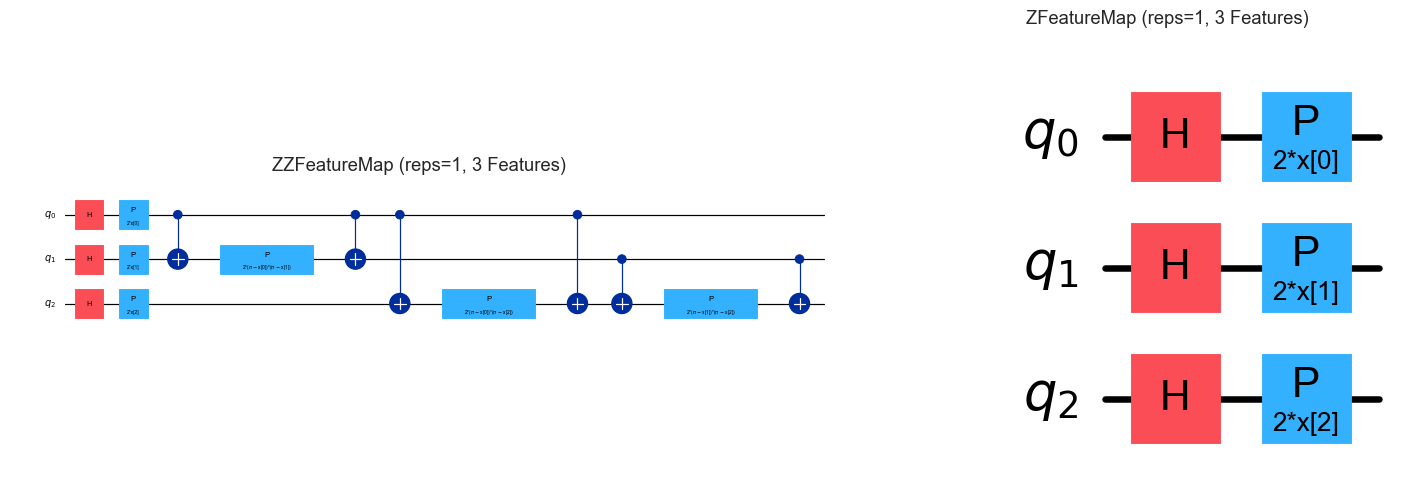

In [29]:
# 특성 맵 회로 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ZZFeatureMap
zz_qc = ZZFeatureMap(feature_dimension=3, reps=1).decompose()
zz_qc.draw('mpl', ax=axes[0], fold=20)
axes[0].set_title('ZZFeatureMap (reps=1, 3 Features)')

# ZFeatureMap
z_qc = ZFeatureMap(feature_dimension=3, reps=1).decompose()
z_qc.draw('mpl', ax=axes[1], fold=20)
axes[1].set_title('ZFeatureMap (reps=1, 3 Features)')

plt.tight_layout()
plt.show()

In [30]:
# reps 변화에 따른 특성 맵 깊이 비교
reps_list = [1, 2, 3, 4, 5]
zz_depths = []
z_depths = []

print("reps에 따른 특성 맵 깊이\n")
print(f"{'reps':<8} {'ZZFeatureMap 깊이':<20} {'ZFeatureMap 깊이':<20}")
print("-" * 50)

for rep in reps_list:
    zz = ZZFeatureMap(feature_dimension=4, reps=rep).decompose()
    z = ZFeatureMap(feature_dimension=4, reps=rep).decompose()
    
    zz_depth = zz.depth()
    z_depth = z.depth()
    
    zz_depths.append(zz_depth)
    z_depths.append(z_depth)
    
    print(f"{rep:<8} {zz_depth:<20} {z_depth:<20}")

reps에 따른 특성 맵 깊이

reps     ZZFeatureMap 깊이      ZFeatureMap 깊이      
--------------------------------------------------
1        17                   2                   
2        31                   4                   
3        45                   6                   
4        59                   8                   
5        73                   10                  


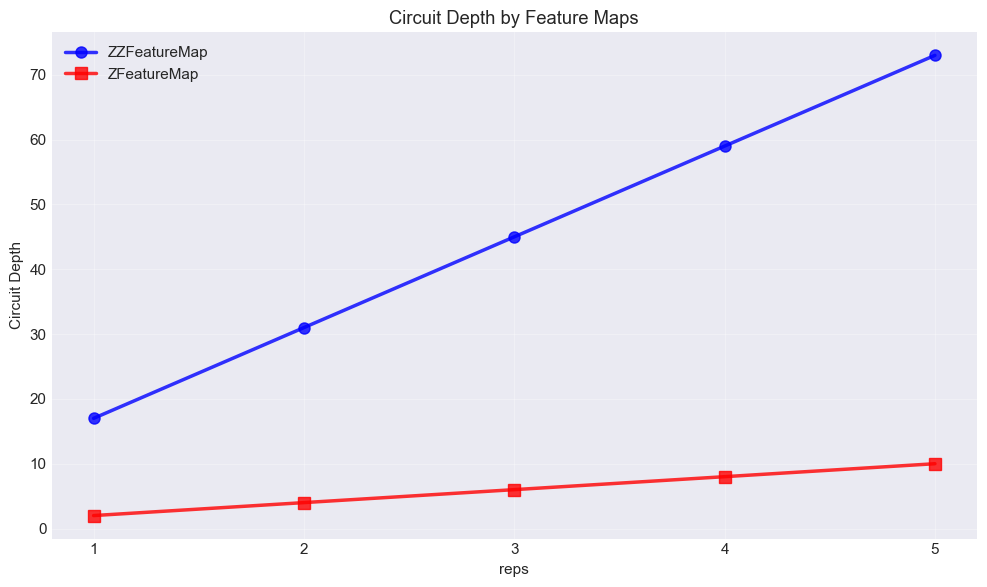


결론: ZZFeatureMap이 더 복잡한 엔탱글먼트 구조를 제공하지만 깊이도 더 크다!


In [31]:
# 표현력 비교 시각화
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(reps_list, zz_depths, 'o-', linewidth=2.5, markersize=8, 
        label='ZZFeatureMap', color='blue', alpha=0.8)
ax.plot(reps_list, z_depths, 's-', linewidth=2.5, markersize=8, 
        label='ZFeatureMap', color='red', alpha=0.8)

ax.set_xlabel('reps')
ax.set_ylabel('Circuit Depth')
ax.set_title('Circuit Depth by Feature Maps')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(reps_list)
plt.tight_layout()
plt.show()

print("\n결론: ZZFeatureMap이 더 복잡한 엔탱글먼트 구조를 제공하지만 깊이도 더 크다!")

In [2]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright